# Tâche 1 : Validation croisée selon les sites

## Contexte

Les données ABIDE proviennent de **plusieurs sites d'acquisition** (scanners, paramètres, populations différents). Ces différences inter-sites peuvent introduire des biais dans les modèles de machine learning : un modèle peut apprendre à reconnaître un site plutôt qu'une vraie signature biologique de l'autisme.

## Objectif

Comparer deux stratégies de validation croisée pour évaluer dans quelle mesure les performances du modèle reflètent une vraie capacité de classification vs. un artefact de site :

1. **Split-half stratifié par site** (*intra-site*) : les données d'entraînement et de test proviennent des **mêmes sites**, chaque site étant représenté proportionnellement dans les deux ensembles. On répète ce split 5 fois (5-fold) pour avoir une estimation stable.
2. **Leave-One-Site-Out (LOSO)** (*inter-site*) : à chaque fold, les données de test proviennent d'un **site entier jamais vu** à l'entraînement. C'est un test de généralisation beaucoup plus exigeant.

**Hypothèse** : si les performances chutent fortement en LOSO vs. intra-site, cela suggère que le modèle exploite les effets de site plutôt que des features neurobiologiques.

## Instructions de reproduction

Ce notebook suppose que les données ABIDE ont déjà été préparées. Voici les étapes :

```bash
# 1. Cloner le dépôt de base
git clone https://github.com/evavilleneuve/abide-fmri.git
cd abide-fmri

# 2. Installer l'environnement
python3 -m venv venv_abide
source venv_abide/bin/activate
pip install --upgrade pip
pip install -r requirements-modern.txt

# 3. Générer les features
mkdir -p data output
python code/prepare_data.py data output
```

Ce notebook utilise des **chemins relatifs** (`data/` et `output/`) afin d'être reproductible sur n'importe quelle machine.

## 1. Imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

## 2. Chargement des données

In [2]:
# Chemins relatifs depuis le dossier du notebook
project_root = Path.cwd().parent
data_path = project_root / "output" / "ABIDE_BASC064_features.npz"
data_dir  = project_root / "data"

assert data_path.exists(), f"Fichier introuvable : {data_path}. Avez-vous exécuté prepare_data.py ?"

# Features
data = np.load(data_path, allow_pickle=True)
X = data["a"]

# Phénotype et étiquettes de site
abide = datasets.fetch_abide_pcp(
    data_dir=str(data_dir),
    pipeline="cpac",
    quality_checked=True
)
pheno = pd.DataFrame(abide.phenotypic)

y    = (pheno["DX_GROUP"] == 1).astype(int).to_numpy()  # 1=ASD, 0=TD
site = pheno["SITE_ID"].to_numpy()

# Vérifications de base
assert X.shape[0] == len(y) == len(site), "Désalignement entre X, y et site !"
print(f"X : {X.shape}  |  ASD : {y.sum()}  TD : {(y==0).sum()}")
print(f"Sites ({len(np.unique(site))}) : {np.unique(site)}")

[fetch_abide_pcp] Dataset found in /mnt/d/udem/PSY3019/PSY3019_abide_projet/data/ABIDE_pcp
X : (871, 2016)  |  ASD : 403  TD : 468
Sites (20) : ['CALTECH' 'CMU' 'KKI' 'LEUVEN_1' 'LEUVEN_2' 'MAX_MUN' 'NYU' 'OHSU' 'OLIN'
 'PITT' 'SBL' 'SDSU' 'STANFORD' 'TRINITY' 'UCLA_1' 'UCLA_2' 'UM_1' 'UM_2'
 'USM' 'YALE']


## 3. Définition du modèle

Régression logistique avec standardisation des features. On utilisera `clone(base_model)` à chaque évaluation pour s'assurer que le pipeline est **toujours réinitialisé** — évite toute fuite d'information entre folds.

In [3]:
base_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, random_state=42))
])

## 4. Stratégie 1 : 5-Fold stratifié par site (intra-site)

Pour chaque fold, on divise **chaque site séparément** en train/test avec `StratifiedKFold`, puis on rassemble les indices. Cela garantit que :
- tous les sites sont présents dans les deux ensembles,
- le ratio ASD/TD est respecté au sein de chaque site.

On répète l'opération sur 5 folds pour avoir une estimation stable (plutôt qu'un seul split 50/50 dépendant du `random_state`).

In [4]:
def kfold_within_site(X, y, site, n_splits=5, random_state=42):
    """
    Génère des folds train/test en stratifiant par site.
    Pour chaque fold, chaque site contribue proportionnellement
    au train et au test.
    Retourne une liste de tuples (train_idx, test_idx).
    """
    site_fold_indices = {s: [] for s in np.unique(site)}

    for s in np.unique(site):
        idx_s = np.where(site == s)[0]
        y_s   = y[idx_s]

        if len(np.unique(y_s)) < 2:
            warnings.warn(
                f"Site '{s}' n'a qu'une seule classe ({np.unique(y_s)}) "
                f"et ne peut pas être stratifié. Il sera ignoré.",
                UserWarning
            )
            continue

        min_class_count = np.bincount(y_s).min()

        if min_class_count < 2:
            warnings.warn(
                f"Site '{s}' : classe minoritaire = {min_class_count} sujet, "
                f"impossible de faire un split. Site ignoré.", UserWarning
            )
            continue

        effective_splits = min(n_splits, min_class_count)
        if effective_splits < n_splits:
            warnings.warn(
                f"Site '{s}' : classe minoritaire = {min_class_count} sujets, "
                f"n_splits réduit à {effective_splits}.", UserWarning
            )

        skf = StratifiedKFold(n_splits=effective_splits, shuffle=True, random_state=random_state)
        folds_s = [(idx_s[tr], idx_s[te]) for tr, te in skf.split(idx_s, y_s)]
        site_fold_indices[s] = folds_s

    valid_sites = [s for s in site_fold_indices if len(site_fold_indices[s]) > 0]
    folds = []
    for fold_i in range(n_splits):
        train_all, test_all = [], []
        for s in valid_sites:
            folds_s = site_fold_indices[s]
            fi = fold_i % len(folds_s)
            train_all.extend(folds_s[fi][0])
            test_all.extend(folds_s[fi][1])
        folds.append((np.array(train_all), np.array(test_all)))

    return folds


def evaluate_cv(folds, X, y, base_model):
    """
    Évalue le modèle sur une liste de folds (train_idx, test_idx).
    Retourne un DataFrame avec accuracy, balanced_accuracy et roc_auc par fold.
    """
    results = []
    for fold_i, (train_idx, test_idx) in enumerate(folds):
        model = clone(base_model)
        model.fit(X[train_idx], y[train_idx])
        y_pred  = model.predict(X[test_idx])
        y_score = model.predict_proba(X[test_idx])[:, 1]

        if len(np.unique(y[test_idx])) < 2:
            warnings.warn(f"Fold {fold_i} : une seule classe dans le test, ROC-AUC non calculé.", UserWarning)
            auc = np.nan
        else:
            auc = roc_auc_score(y[test_idx], y_score)

        results.append({
            "fold":              fold_i,
            "accuracy":          accuracy_score(y[test_idx], y_pred),
            "balanced_accuracy": balanced_accuracy_score(y[test_idx], y_pred),
            "roc_auc":           auc,
        })
    return pd.DataFrame(results)

In [6]:
folds_intra = kfold_within_site(X, y, site, n_splits=5)
results_intra = evaluate_cv(folds_intra, X, y, base_model)

print("=== Intra-site (5-fold stratifié par site) ===")
print(results_intra.round(3).to_string(index=False))
print("\nMoyenne :")
print(results_intra[["accuracy", "balanced_accuracy", "roc_auc"]].mean().round(3))

=== Intra-site (5-fold stratifié par site) ===
 fold  accuracy  balanced_accuracy  roc_auc
    0     0.710              0.704    0.748
    1     0.616              0.612    0.683
    2     0.672              0.671    0.729
    3     0.676              0.675    0.714
    4     0.593              0.593    0.641

Moyenne :
accuracy             0.654
balanced_accuracy    0.651
roc_auc              0.703
dtype: float64


Ce que ça veut dire : Quand les mêmes sites sont vus à l'entraînement et au test, le modèle classe correctement ~65% des participants et a un AUC de 0.70 c'est modeste mais cohérent

La variabilité entre folds est notable (accuracy entre 0.593 et 0.710), ce qui reflète l'hétérogénéité des sites ABIDE.

## 5. Stratégie 2 : Leave-One-Site-Out (LOSO)

À chaque fold, **un site entier** est mis de côté comme ensemble de test. Le modèle est entraîné sur tous les autres sites. Cela simule le scénario réaliste où on voudrait appliquer le modèle à un nouveau site non vu lors de l'entraînement.

In [7]:
logo = LeaveOneGroupOut()
results_loso = []

for train_idx, test_idx in logo.split(X, y, groups=site):
    site_test = np.unique(site[test_idx])[0]
    model = clone(base_model)  # réinitialisation propre à chaque fold
    model.fit(X[train_idx], y[train_idx])
    y_pred  = model.predict(X[test_idx])
    y_score = model.predict_proba(X[test_idx])[:, 1]

    if len(np.unique(y[test_idx])) < 2:
        warnings.warn(f"Site '{site_test}' : une seule classe dans le test, ROC-AUC non calculé.", UserWarning)
        auc = np.nan
    else:
        auc = roc_auc_score(y[test_idx], y_score)

    results_loso.append({
        "site":              site_test,
        "n_test":            len(test_idx),
        "accuracy":          accuracy_score(y[test_idx], y_pred),
        "balanced_accuracy": balanced_accuracy_score(y[test_idx], y_pred),
        "roc_auc":           auc,
    })

results_loso = pd.DataFrame(results_loso).sort_values("balanced_accuracy", ascending=False)

print("=== LOSO — résultats par site ===")
print(results_loso.round(3).to_string(index=False))
print("\nMoyenne (pondérée par n_test) :")
weights = results_loso["n_test"] / results_loso["n_test"].sum()
for col in ["accuracy", "balanced_accuracy", "roc_auc"]:
    val = (results_loso[col] * weights).sum()
    print(f"  {col}: {val:.3f}")

=== LOSO — résultats par site ===
    site  n_test  accuracy  balanced_accuracy  roc_auc
LEUVEN_1      28     0.750              0.750    0.663
LEUVEN_2      28     0.750              0.740    0.740
    PITT      50     0.740              0.737    0.777
    SDSU      27     0.778              0.734    0.796
    UM_1      86     0.733              0.723    0.800
     USM      67     0.687              0.719    0.787
    OLIN      28     0.714              0.714    0.740
    UM_2      34     0.735              0.712    0.835
    YALE      41     0.707              0.709    0.833
     KKI      33     0.667              0.685    0.730
     NYU     172     0.634              0.654    0.725
     CMU      11     0.636              0.633    0.700
 TRINITY      44     0.591              0.621    0.703
  UCLA_1      64     0.609              0.617    0.717
     SBL      26     0.615              0.613    0.554
  UCLA_2      21     0.619              0.609    0.709
STANFORD      25     0.600     

**NOTE** : verifier le fait que le n change selon le site est ce que ca a beaucoup d'effet !!!

Ici on voit la variabilité par site

Sites faciles (LEUVEN_1, LEUVEN_2, PITT, SDSU) → balanced accuracy ~0.73–0.75
Sites difficiles (OHSU, CALTECH, MAX_MUN) → balanced accuracy ~0.45–0.50, soit niveau du hasard

OHSU à 0.442 et MAX_MUN à 0.499 veulent dire que le modèle ne généralise pas du tout à ces sites.

## 6. Comparaison visuelle des deux stratégies

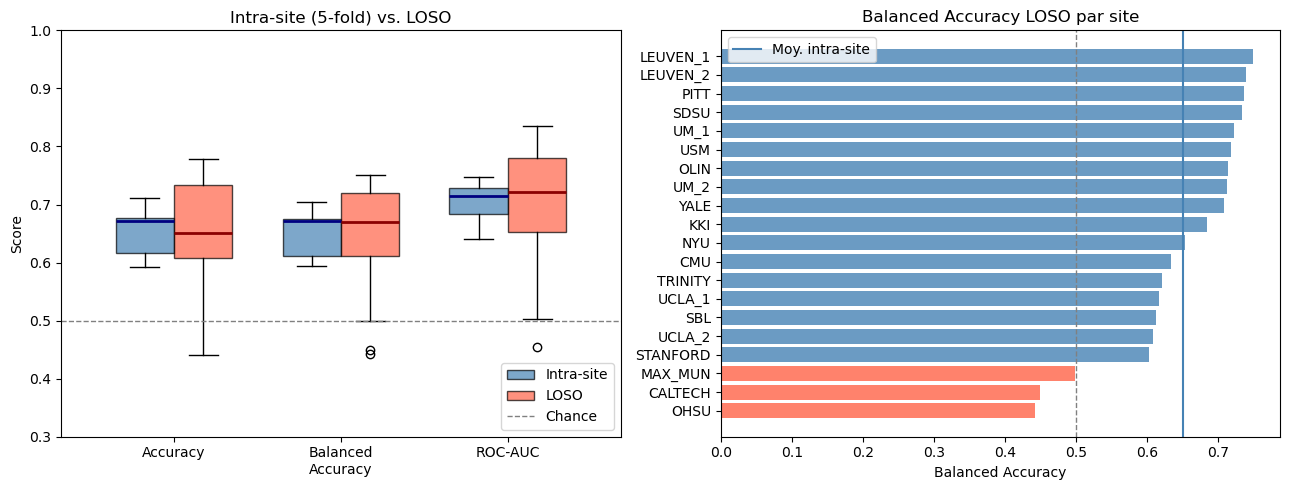

Figure sauvegardée : comparaison_cv.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panneau gauche : boxplot comparatif ---
metrics = ["accuracy", "balanced_accuracy", "roc_auc"]
labels  = ["Accuracy", "Balanced\nAccuracy", "ROC-AUC"]

intra_vals = [results_intra[m].dropna().values for m in metrics]
loso_vals  = [results_loso[m].dropna().values  for m in metrics]

x = np.arange(len(metrics))
width = 0.35

bp1 = axes[0].boxplot(intra_vals, positions=x - width/2, widths=width,
                       patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.7),
                       medianprops=dict(color="navy", linewidth=2))
bp2 = axes[0].boxplot(loso_vals,  positions=x + width/2, widths=width,
                       patch_artist=True, boxprops=dict(facecolor="tomato", alpha=0.7),
                       medianprops=dict(color="darkred", linewidth=2))

axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chance (0.5)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Score")
axes[0].set_title("Intra-site (5-fold) vs. LOSO")
axes[0].legend([bp1["boxes"][0], bp2["boxes"][0], axes[0].lines[-1]],
               ["Intra-site", "LOSO", "Chance"],
               loc="lower right")
axes[0].set_ylim(0.3, 1.0)

# --- Panneau droit : balanced_accuracy LOSO par site ---
loso_sorted = results_loso.sort_values("balanced_accuracy")
colors = ["tomato" if v < 0.5 else "steelblue" for v in loso_sorted["balanced_accuracy"]]
axes[1].barh(loso_sorted["site"], loso_sorted["balanced_accuracy"], color=colors, alpha=0.8)
axes[1].axvline(0.5, color="gray", linestyle="--", linewidth=1)
axes[1].axvline(results_intra["balanced_accuracy"].mean(), color="steelblue",
                linestyle="-", linewidth=1.5, label="Moy. intra-site")
axes[1].set_xlabel("Balanced Accuracy")
axes[1].set_title("Balanced Accuracy LOSO par site")
axes[1].legend()

plt.tight_layout()
plt.savefig("comparaison_cv.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : comparaison_cv.png")

La figure 2 illustre l'hétérogénéité inter-site : 3 sites sur 20 (MAX_MUN, CALTECH, OHSU) obtiennent une balanced accuracy inférieure à 0.5 en LOSO, soit en dessous du niveau du hasard, tandis que la majorité des sites dépasse la moyenne intra-site.

## 7. Discussion

### Résumé des résultats

| Stratégie | Balanced Accuracy (moy.) | ROC-AUC (moy.) |
|---|---|---|
| Intra-site (5-fold) | *0.651* | *0.703* |
| LOSO | *0.661* | *0.718* |

### Interprétation

**Absence de chute en LOSO**

Contrairement à ce qu'on aurait pu anticiper, les performances en LOSO sont légèrement supérieures à celles obtenues en intra-site (balanced accuracy : 0.661 vs 0.651). Cela suggère que les effets de site ne dominent pas globalement les performances du modèle : celui-ci capture des caractéristiques suffisamment généralisables pour classer correctement des participants issus de sites non vus à l'entraînement. Toutefois, ce résultat doit être interprété avec prudence, car la validation intra-site a été contrainte à 2 folds effectifs par site en raison d'un nombre limité de sujets par classe, ce qui peut avoir sous-estimé les performances intra-site.

**Forte hétérogénéité inter-site**

La variabilité des performances LOSO entre sites est la principale observation de cette tâche. On distingue deux groupes :

- Sites bien généralisés (LEUVEN_1, LEUVEN_2, PITT, SDSU) : balanced accuracy entre 0.73 et 0.75, indiquant que le modèle entraîné sur les autres sites prédit correctement ces populations.
- Sites problématiques (OHSU : 0.442, CALTECH : 0.450, MAX_MUN : 0.499) : performances au niveau du hasard. Le modèle échoue complètement à généraliser à ces sites, ce qui suggère que leurs données présentent des caractéristiques spécifiques non représentées dans les autres sites (protocole d'acquisition particulier, population atypique en termes d'âge ou de sévérité clinique).


**Limites**

Cette analyse repose sur un seul modèle (régression logistique) et un seul type de features (connectivité fonctionnelle BASC064). Les résultats pourraient différer avec un modèle plus complexe ou des features différentes. Par ailleurs, la taille très réduite de certains sites (CMU : 11 sujets, CALTECH : 15 sujets) limite la fiabilité des estimations LOSO pour ces sites spécifiquement.

**Conclusion**

La stratégie LOSO révèle que les performances moyennes du modèle sont relativement robustes aux effets de site, mais masquent une hétérogénéité importante : pour certains sites, la généralisation est quasi nulle. Pour tout déploiement clinique multi-sites, il serait donc essentiel de valider le modèle explicitement sur chaque nouveau site avant utilisation, plutôt que de se fier à une performance moyenne agrégée.

